<a href="https://colab.research.google.com/github/Saluja50/ted-talk-views-prediction-model/blob/main/ted_talk_views_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - ted talk views prediction model




##### **Project Type**    - Regression
##### **Contribution**    - Individual


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/Saluja50/ted-talk-views-prediction-model




# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [71]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
import math
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

### Dataset Loading

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
# Load Dataset
dataset = pd.read_csv("/content/drive/MyDrive/Copy of data_ted_talks.csv",encoding = 'latin1')
df = dataset.copy()

### Dataset First View

In [74]:
# Dataset First Look
df.head()

,talk_id,title,speaker_1,all_speakers,occupations,about_speakers,views,recorded_date,published_date,event,native_lang,available_lang,comments,duration,topics,related_talks,url,description,transcript
0,1,Averting the climate crisis,Al Gore,{0: 'Al Gore'},{0: ['climate advocate']},{0: 'Nobel Laureate Al Gore focused the worldâ...,3523392,2006-02-25,2006-06-27,TED2006,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,"['alternative energy', 'cars', 'climate change...","{243: 'New thinking on the climate crisis', 54...",https://www.ted.com/talks/al_gore_averting_the...,With the same humor and humanity he exuded in ...,"Thank you so much, Chris. And it's truly a gre..."
1,92,The best stats you've ever seen,Hans Rosling,{0: 'Hans Rosling'},{0: ['global health expert; data visionary']},"{0: 'In Hans Roslingâs hands, data sings. Gl...",14501685,2006-02-22,2006-06-27,TED2006,en,"['ar', 'az', 'bg', 'bn', 'bs', 'cs', 'da', 'de...",628.0,1190,"['Africa', 'Asia', 'Google', 'demo', 'economic...","{2056: ""Own your body's data"", 2296: 'A visual...",https://www.ted.com/talks/hans_rosling_the_bes...,You've never seen data presented like this. Wi...,"About 10 years ago, I took on the task to teac..."
2,7,Simplicity sells,David Pogue,{0: 'David Pogue'},{0: ['technology columnist']},{0: 'David Pogue is the personal technology co...,1920832,2006-02-24,2006-06-27,TED2006,en,"['ar', 'bg', 'de', 'el', 'en', 'es', 'fa', 'fr...",124.0,1286,"['computers', 'entertainment', 'interface desi...","{1725: '10 top time-saving tech tips', 2274: '...",https://www.ted.com/talks/david_pogue_simplici...,New York Times columnist David Pogue takes aim...,"(Music: ""The Sound of Silence,"" Simon & Garfun..."
3,53,Greening the ghetto,Majora Carter,{0: 'Majora Carter'},{0: ['activist for environmental justice']},{0: 'Majora Carter redefined the field of envi...,2664069,2006-02-26,2006-06-27,TED2006,en,"['ar', 'bg', 'bn', 'ca', 'cs', 'de', 'en', 'es...",219.0,1116,"['MacArthur grant', 'activism', 'business', 'c...",{1041: '3 stories of local eco-entrepreneurshi...,https://www.ted.com/talks/majora_carter_greeni...,"In an emotionally charged talk, MacArthur-winn...",If you're here today â and I'm very happy th...
4,66,Do schools kill creativity?,Sir Ken Robinson,{0: 'Sir Ken Robinson'},"{0: ['author', 'educator']}","{0: ""Creativity expert Sir Ken Robinson challe...",65051954,2006-02-25,2006-06-27,TED2006,en,"['af', 'ar', 'az', 'be', 'bg', 'bn', 'ca', 'cs...",4931.0,1164,"['children', 'creativity', 'culture', 'dance',...","{865: 'Bring on the learning revolution!', 173...",https://www.ted.com/talks/sir_ken_robinson_do_...,Sir Ken Robinson makes an entertaining and pro...,Good morning. How are you? (Audience) Good. It...


### Dataset Rows & Columns count

In [75]:
# Dataset Rows & Columns count
df.shape

(4005, 19)

### Dataset Information

In [76]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   talk_id         4005 non-null   int64  
 1   title           4005 non-null   object 
 2   speaker_1       4005 non-null   object 
 3   all_speakers    4001 non-null   object 
 4   occupations     3483 non-null   object 
 5   about_speakers  3502 non-null   object 
 6   views           4005 non-null   int64  
 7   recorded_date   4004 non-null   object 
 8   published_date  4005 non-null   object 
 9   event           4005 non-null   object 
 10  native_lang     4005 non-null   object 
 11  available_lang  4005 non-null   object 
 12  comments        3350 non-null   float64
 13  duration        4005 non-null   int64  
 14  topics          4005 non-null   object 
 15  related_talks   4005 non-null   object 
 16  url             4005 non-null   object 
 17  description     4005 non-null   o

#### Duplicate Values

In [77]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

#### Missing Values/Null Values

In [78]:
# Missing Values/Null Values Count
print(df.isnull().sum())

talk_id             0
title               0
speaker_1           0
all_speakers        4
occupations       522
about_speakers    503
views               0
recorded_date       1
published_date      0
event               0
native_lang         0
available_lang      0
comments          655
duration            0
topics              0
related_talks       0
url                 0
description         0
transcript          0
dtype: int64


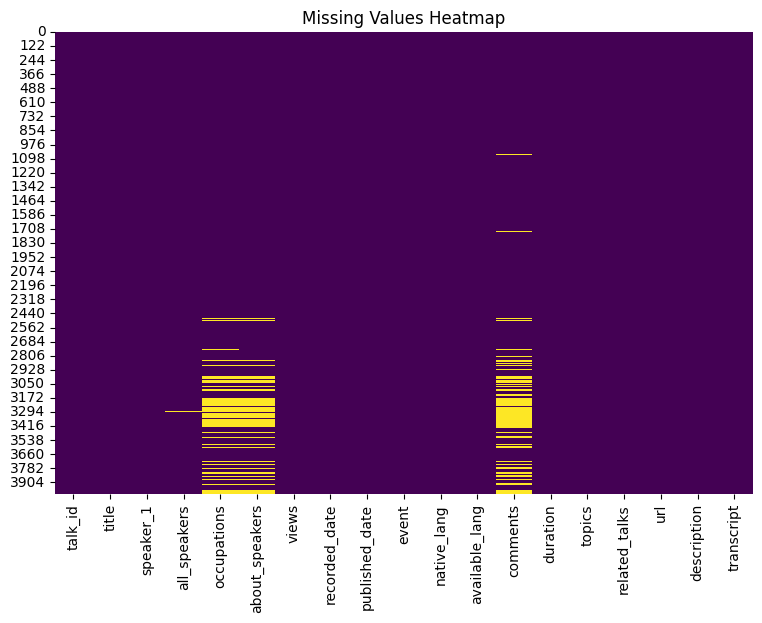

In [79]:
# Visualizing the missing values
# by heat map
plt.figure(figsize=(9,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

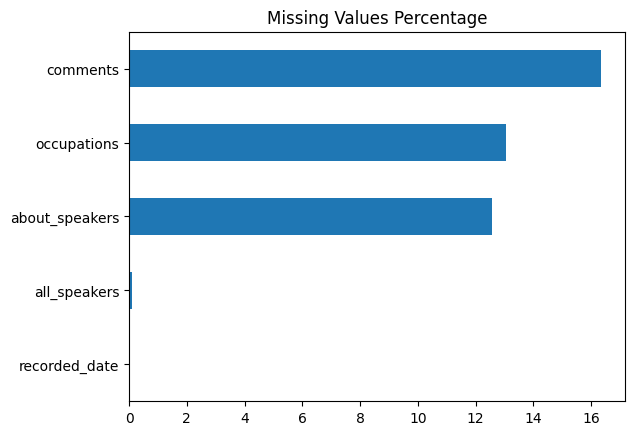

In [80]:
# by percentage plot
null_percent = (df.isnull().sum() / len(df)) * 100

null_percent = null_percent[null_percent > 0]

null_percent.sort_values().plot(kind='barh')
plt.title("Missing Values Percentage")
plt.show()

### What did you know about your dataset?

The dataset contains TED Talks data with a mix of numerical, categorical, and textual features. I observed that most columns are clean, but some like comments, occupations, and about_speakers have significant missing values. The missing data is not randomly distributed, indicating possible data collection issues. I also identified key features like views and comments as important for analysis, while some text heavy columns may not add much value. Overall, the dataset is mostly clean but requires preprocessing before deeper analysis.

## ***2. Understanding Your Variables***

In [81]:
# Dataset Columns
df.columns

Index(['talk_id', 'title', 'speaker_1', 'all_speakers', 'occupations',
       'about_speakers', 'views', 'recorded_date', 'published_date', 'event',
       'native_lang', 'available_lang', 'comments', 'duration', 'topics',
       'related_talks', 'url', 'description', 'transcript'],
      dtype='object')

In [82]:
# Dataset Describe
df.describe()

,talk_id,views,comments,duration
count,4005.000000,4.005000e+03,3350.000000,4005.000000
mean,12432.538327,2.148006e+06,161.997015,724.011236
std,17447.576262,3.451226e+06,268.838922,361.775462
min,1.000000,0.000000e+00,0.000000,60.000000
25%,1252.000000,8.820690e+05,38.000000,393.000000
50%,2333.000000,1.375508e+06,89.000000,738.000000
75%,23777.000000,2.133110e+06,188.000000,974.000000
max,62794.000000,6.505195e+07,6449.000000,3922.000000


### Variables Description

**talk_id**: Unique ID of each talk

**title** : Title of the TED Talk

**speaker_1** : Main speaker of the talk

**all_speakers** : List of all speakers involved in the talk

**occupations** : Professions of the speakers

**about_speakers** : Description or bio of the speakers

**views**: Total number of views of the talk

**recorded_date** : Date when the talk was recorded

**published_date** : Date when the talk was published

**event** : Event where the talk was presented

**native_lang** : Original language of the talk

**available_lang** : Number of languages available for subtitles

**comments** : Total number of comments on the talk

**duration**: Length of the talk in seconds

**topics** : Topics or tags related to the talk

**related_talks** : List of related TED Talks

**url** : Link to the TED Talk

**description** : Short summary of the talk

**transcript** : Full text transcript of the talk



### Check Unique Values for each variable.

In [83]:
# Check Unique Values for each variable.
for i in df.columns:
  print("No. of unique values in ",i,"is",df[i].nunique(),".")

No. of unique values in  talk_id is 4005 .
No. of unique values in  title is 4005 .
No. of unique values in  speaker_1 is 3274 .
No. of unique values in  all_speakers is 3306 .
No. of unique values in  occupations is 2049 .
No. of unique values in  about_speakers is 2977 .
No. of unique values in  views is 3996 .
No. of unique values in  recorded_date is 1334 .
No. of unique values in  published_date is 2962 .
No. of unique values in  event is 459 .
No. of unique values in  native_lang is 12 .
No. of unique values in  available_lang is 3902 .
No. of unique values in  comments is 601 .
No. of unique values in  duration is 1188 .
No. of unique values in  topics is 3977 .
No. of unique values in  related_talks is 4005 .
No. of unique values in  url is 4005 .
No. of unique values in  description is 4005 .
No. of unique values in  transcript is 4005 .


## 3. ***Data Wrangling***

### Data Wrangling Code

In [84]:
# Write your code to make your dataset analysis ready.
# 1.unwanted columns
df = df.drop(['talk_id', 'url', 'related_talks'], axis=1)
df.columns





Index(['title', 'speaker_1', 'all_speakers', 'occupations', 'about_speakers',
       'views', 'recorded_date', 'published_date', 'event', 'native_lang',
       'available_lang', 'comments', 'duration', 'topics', 'description',
       'transcript'],
      dtype='object')

In [85]:
#2. removing missing vslues and filling
df = df.drop(['occupations', 'about_speakers'], axis=1)
df['comments'] = df['comments'].fillna(df['comments'].median())

In [86]:
#3 changing data type and feature engineering
df['published_date'] = pd.to_datetime(df['published_date'])
df['recorded_date'] = pd.to_datetime(df['recorded_date'])
df['year'] = df['published_date'].dt.year
df['engagement'] = df['comments'] / df['views']
df['duration_min'] = df['duration'] / 60

In [87]:
#4converting into numeric
df['title_length'] = df['title'].apply(len)
df['topic_count'] = df['topics'].str.split(',').str.len()

In [88]:
#5 handling skewness
print(df['views'].mean())
print(df['views'].median())

2148005.5737827714
1375508.0


In [89]:
#mean>mode right skewed
#Doing log transformation
df['views'] = np.log1p(df['views'])

In [90]:
#encoding in native lang
df = pd.get_dummies(df, columns=['native_lang'], drop_first=True)

In [91]:
#heavy text columns
df = df.drop(['title', 'description', 'transcript', 'topics'], axis=1)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   speaker_1          4005 non-null   object        
 1   all_speakers       4001 non-null   object        
 2   views              4005 non-null   float64       
 3   recorded_date      4004 non-null   datetime64[ns]
 4   published_date     4005 non-null   datetime64[ns]
 5   event              4005 non-null   object        
 6   available_lang     4005 non-null   object        
 7   comments           4005 non-null   float64       
 8   duration           4005 non-null   int64         
 9   year               4005 non-null   int32         
 10  engagement         4005 non-null   float64       
 11  duration_min       4005 non-null   float64       
 12  title_length       4005 non-null   int64         
 13  topic_count        4005 non-null   int64         
 14  native_l

In [93]:
df.head()

,speaker_1,all_speakers,views,recorded_date,published_date,event,available_lang,comments,duration,year,...,native_lang_en,native_lang_es,native_lang_fr,native_lang_hi,native_lang_it,native_lang_ja,native_lang_ko,native_lang_pt,native_lang_pt-br,native_lang_zh-cn
0,Al Gore,{0: 'Al Gore'},15.074935,2006-02-25,2006-06-27,TED2006,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,2006,...,True,False,False,False,False,False,False,False,False,False
1,Hans Rosling,{0: 'Hans Rosling'},16.489775,2006-02-22,2006-06-27,TED2006,"['ar', 'az', 'bg', 'bn', 'bs', 'cs', 'da', 'de...",628.0,1190,2006,...,True,False,False,False,False,False,False,False,False,False
2,David Pogue,{0: 'David Pogue'},14.468270,2006-02-24,2006-06-27,TED2006,"['ar', 'bg', 'de', 'el', 'en', 'es', 'fa', 'fr...",124.0,1286,2006,...,True,False,False,False,False,False,False,False,False,False
3,Majora Carter,{0: 'Majora Carter'},14.795366,2006-02-26,2006-06-27,TED2006,"['ar', 'bg', 'bn', 'ca', 'cs', 'de', 'en', 'es...",219.0,1116,2006,...,True,False,False,False,False,False,False,False,False,False
4,Sir Ken Robinson,{0: 'Sir Ken Robinson'},17.990697,2006-02-25,2006-06-27,TED2006,"['af', 'ar', 'az', 'be', 'bg', 'bn', 'ca', 'cs...",4931.0,1164,2006,...,True,False,False,False,False,False,False,False,False,False


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

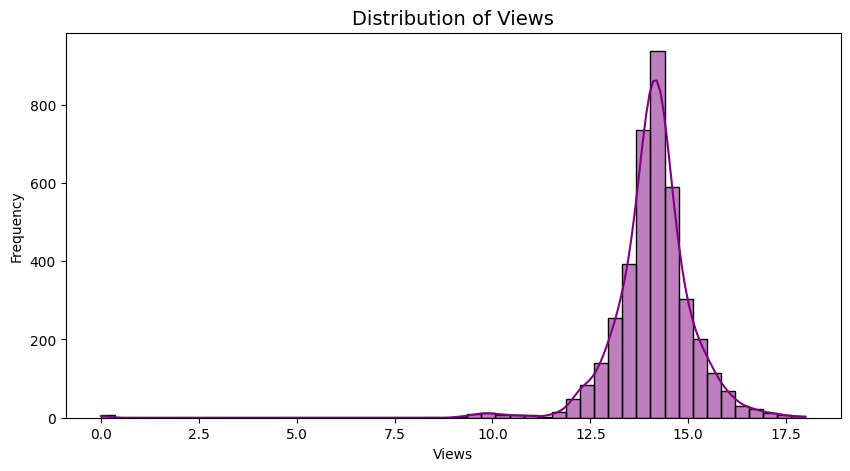

In [94]:
# Chart - 1 distribution of views
plt.figure(figsize=(10,5))
sns.histplot(df['views'], bins=50, kde=True, color='purple')

plt.title("Distribution of Views", fontsize=14)
plt.xlabel("Views")
plt.ylabel("Frequency")

plt.show()


##### 1. Why did you pick the specific chart?



```
# This is formatted as code
```

To analyze the distribution of views and check skewness after transformation.

##### 2. What is/are the insight(s) found from the chart?

Most TED talks have moderate views, with the majority clustered around the mid-range.Only a small number of talks achieve very high views, indicating that viral success is rare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

positive :
Platform has consistent content performance
Most talks reach a reasonable audience

negative:
Only few talks achieve massive reach
Opportunity gap in scaling content success

#### Chart - 2

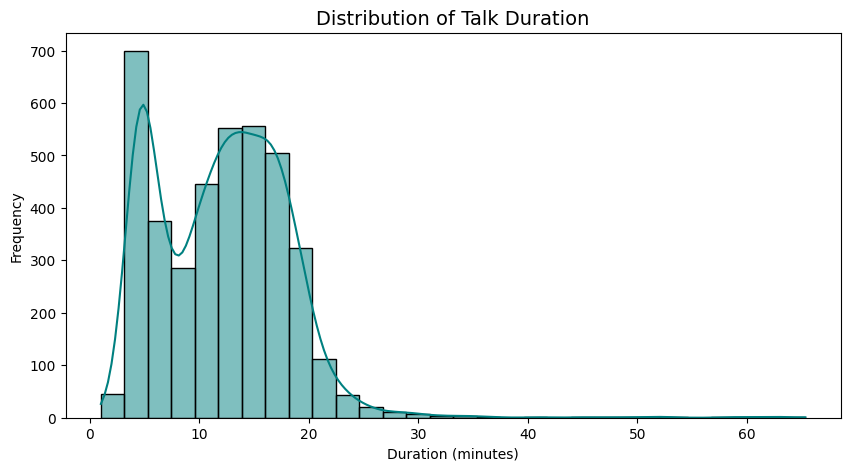

In [95]:
# Chart - Distribution of Duration
plt.figure(figsize=(10,5))
sns.histplot(df['duration_min'], bins=30, kde=True, color='teal')

plt.title("Distribution of Talk Duration", fontsize=14)
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

To understand typical length of TED talks and whether longer talks are common or rare

##### 2. What is/are the insight(s) found from the chart?

Most TED talks are concentrated between 10 to 20 minutes. Very short and very long talks are relatively less common.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Positive:

Helps define ideal talk duration

Useful for content creators to optimize length

Negative:

Very long talks may lose audience attention

Very short talks may lack depth


#### Chart - 3

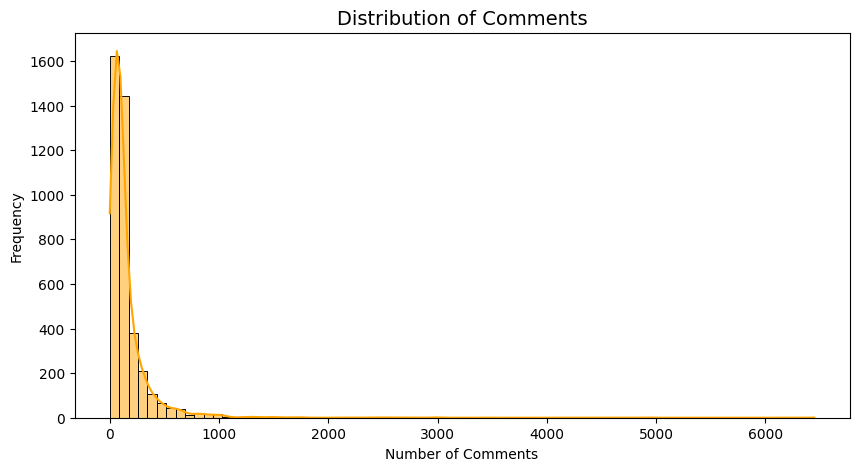

In [96]:
# Chart - 3 Distribution of Comments
plt.figure(figsize=(10,5))
sns.histplot(df['comments'], bins=75, kde=True, color='orange')

plt.title("Distribution of Comments", fontsize=14)
plt.xlabel("Number of Comments")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

To understand
how audience interacts with talks,
Whether engagement is evenly distributed or not

##### 2. What is/are the insight(s) found from the chart?

Most talks receive low to moderate number of comments.

A few talks get very high comments, indicating strong engagement spikes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

Highly engaging talks can build strong community interaction

Opportunity to learn what drives discussions

Negative:

Majority of talks have low engagement

#### Chart - 4

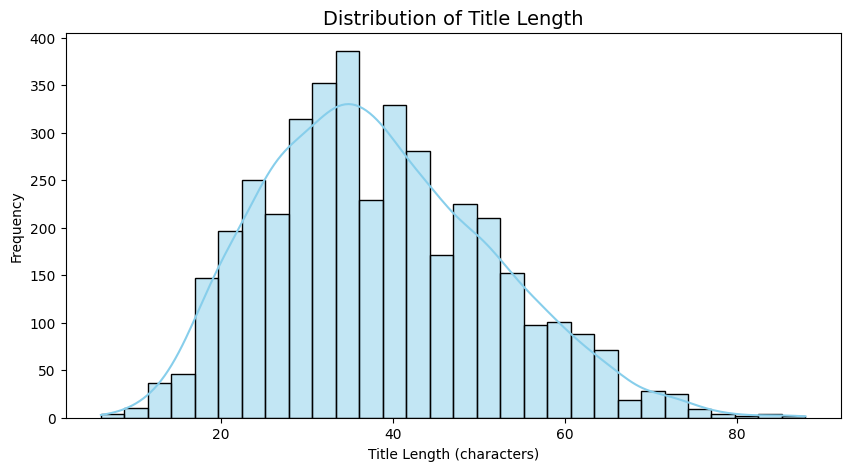

In [97]:
# Chart - 4 Distribution of Title Length
plt.figure(figsize=(10,5))
sns.histplot(df['title_length'], bins=30, kde=True, color='skyblue')

plt.title("Distribution of Title Length", fontsize=14)
plt.xlabel("Title Length (characters)")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

To understand
how long TED talk titles usually are
,Whether short or long titles are common

##### 2. What is/are the insight(s) found from the chart?

Most TED talk titles have moderate length .
Extremely short or very long titles are rare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps define ideal title length for clarity and engagement
Balanced titles improve readability

#### Chart - 5

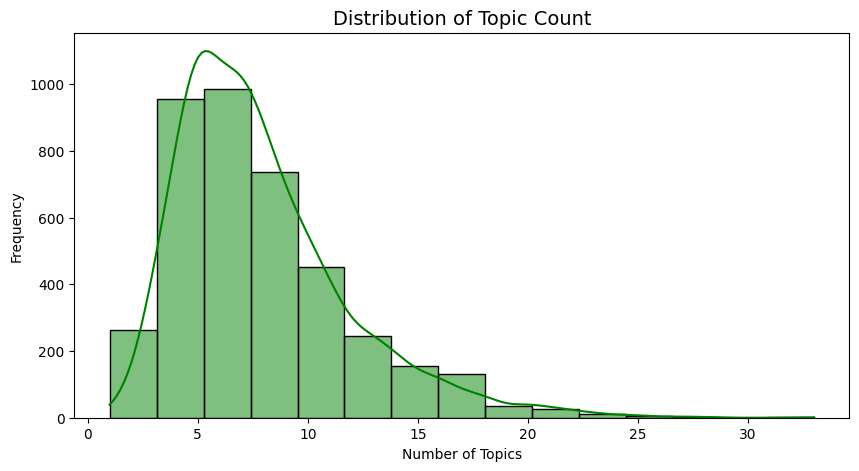

In [98]:
# Chart - 5 Distribution of Topic Count
plt.figure(figsize=(10,5))
sns.histplot(df['topic_count'], bins=15, kde=True, color='green')

plt.title("Distribution of Topic Count", fontsize=14)
plt.xlabel("Number of Topics")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

To understand
how many topics a typical talk covers and
Whether talks are focused or broad

##### 2. What is/are the insight(s) found from the chart?

Most TED talks cover a small number of topics

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focused talks are easier to understand and
improves audience retention

#### Chart - 6

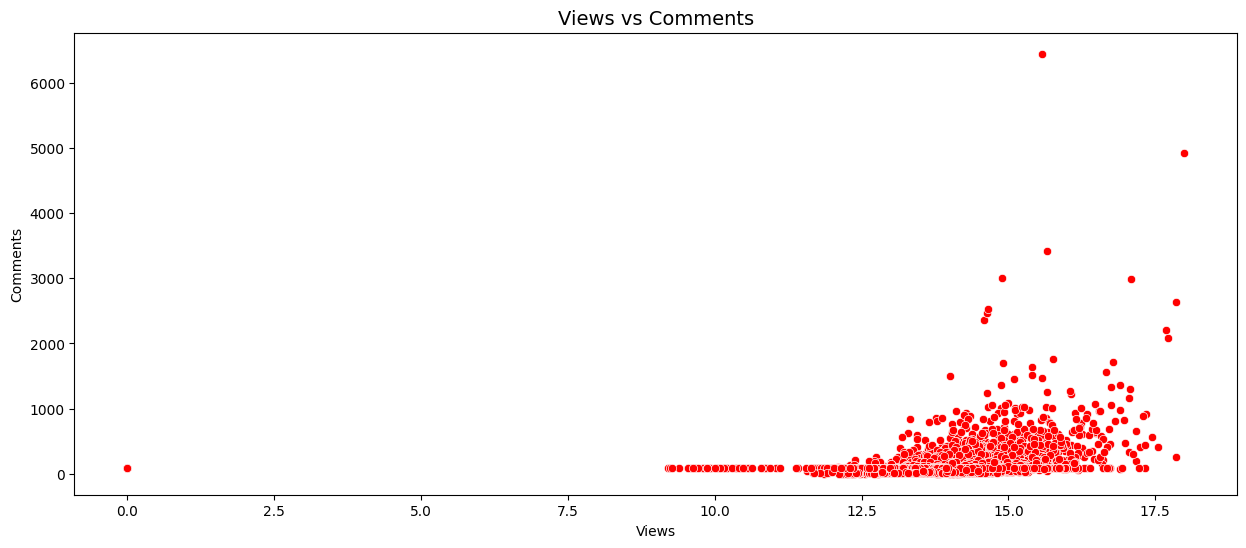

In [99]:
# Chart - 6 Views vs Comments
plt.figure(figsize=(15,6))
sns.scatterplot(x='views', y='comments', data=df, color='red')

plt.title("Views vs Comments", fontsize=14)
plt.xlabel("Views")
plt.ylabel("Comments")

plt.show()

##### 1. Why did you pick the specific chart?

To understand Relationship between views and comments

##### 2. What is/are the insight(s) found from the chart?

There is a positive relationship between views and comments.
Talks with higher views generally receive more comments .

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Increasing views can directly boost engagement



#### Chart - 7

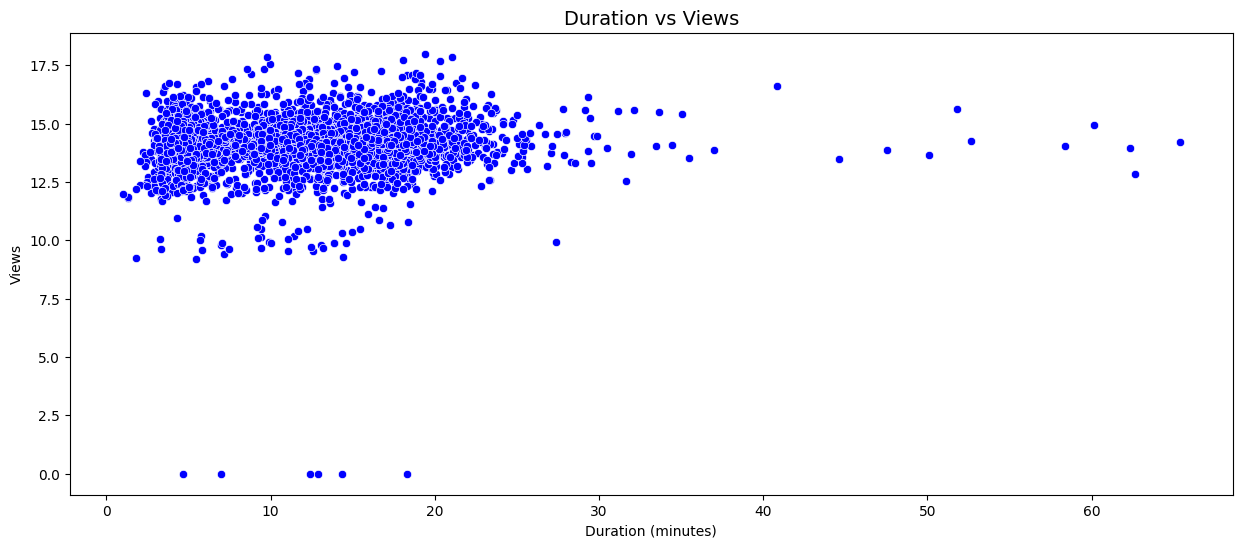

In [100]:
# Chart - 7 Duration vs Views
plt.figure(figsize=(15,6))
sns.scatterplot(x='duration_min', y='views', data=df, color='blue')

plt.title("Duration vs Views", fontsize=14)
plt.xlabel("Duration (minutes)")
plt.ylabel("Views")

plt.show()

##### 1. Why did you pick the specific chart?

To check if longer talk = more views?

##### 2. What is/are the insight(s) found from the chart?

There is no strong relationship between duration and views.
Both short and long talks can perform well, indicating duration alone doesn't decide success.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Success depends more on quality than length

#### Chart - 8

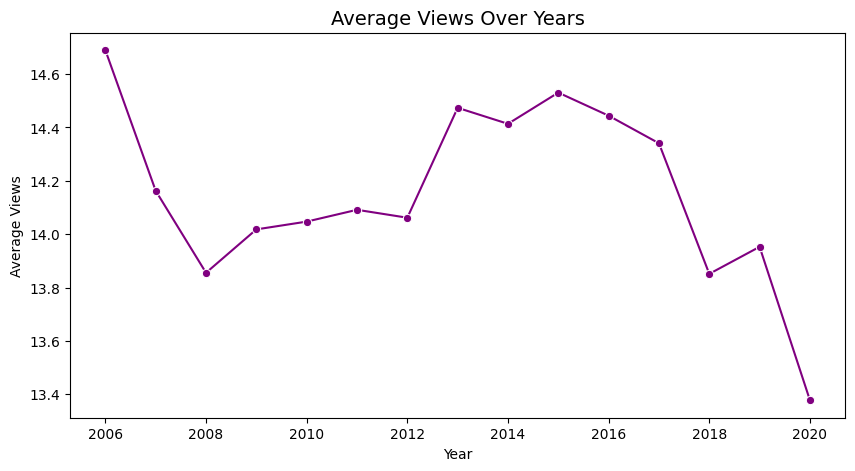

In [101]:
# Chart - 8 Year vs Average Views
plt.figure(figsize=(10,5))

yearly_views = df.groupby('year')['views'].mean().reset_index()

sns.lineplot(x='year', y='views', data=yearly_views, marker='o', color='purple')

plt.title("Average Views Over Years", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Views")

plt.show()

##### 1. Why did you pick the specific chart?

To understand
how TED talks performance changed over time


##### 2. What is/are the insight(s) found from the chart?

Average views increased steadily until around 2015, indicating strong growth in audience engagement. After 2016, a noticeable decline suggests reduced viewership or increased competition

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative:
Declining trend is a warning signal
Platform may be losing attention

#### Chart - 9

/tmp/ipykernel_590/2834060445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='native_lang', y='views', data=dataset, palette='coolwarm')


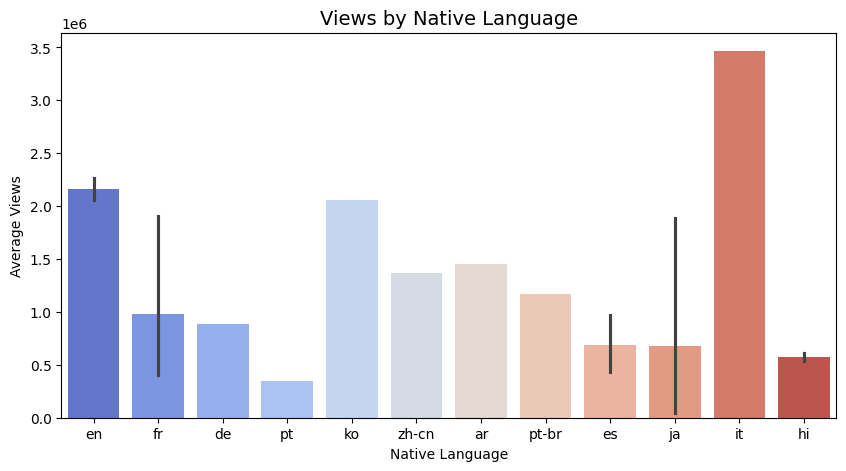

In [102]:
# Chart - 9 Native Language vs Views
plt.figure(figsize=(10,5))

sns.barplot(x='native_lang', y='views', data=dataset, palette='coolwarm')

plt.title("Views by Native Language", fontsize=14)
plt.xlabel("Native Language")
plt.ylabel("Average Views")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare average views across different languages clearly.

##### 2. What is/are the insight(s) found from the chart?

English has consistently high views, showing strong global reach.Italian  shows the highest average views, but this is likely due to a few viral talks

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

English content ensures maximum global audience reach.
High-performing languages like italian indicate potential niche markets worth exploring.

#### Chart - 10

/tmp/ipykernel_590/4276644356.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_speakers.values, y=top_speakers.index, palette='viridis')


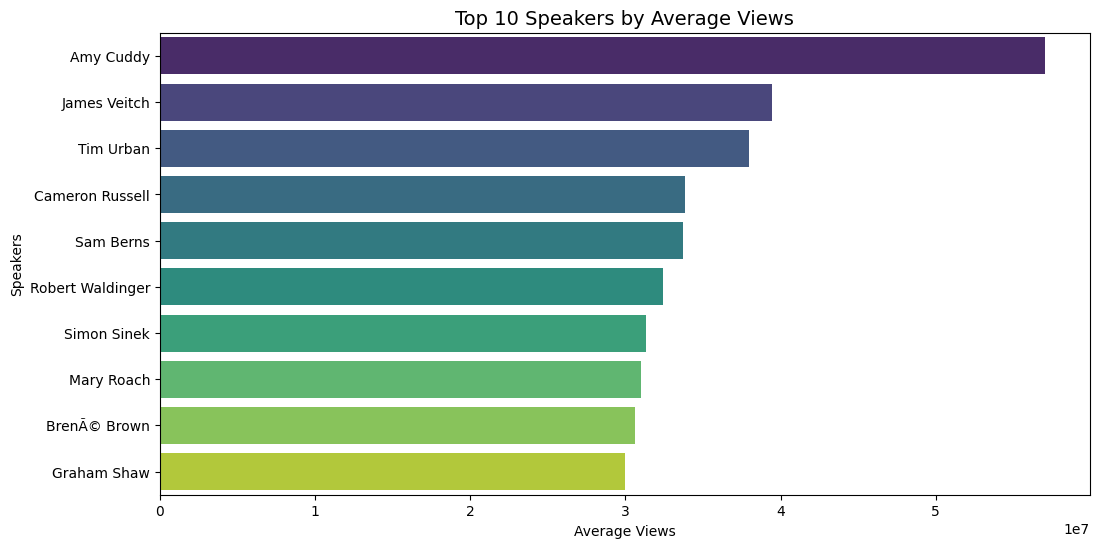

In [103]:
# Chart - 10 Top Speakers by Average Views
plt.figure(figsize=(12,6))

top_speakers = dataset.groupby('speaker_1')['views'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_speakers.values, y=top_speakers.index, palette='viridis')

plt.title("Top 10 Speakers by Average Views", fontsize=14)
plt.xlabel("Average Views")
plt.ylabel("Speakers")

plt.show()

##### 1. Why did you pick the specific chart?

To identify
Which speakers generate highest views ,
Who contributes most to platform success

##### 2. What is/are the insight(s) found from the chart?

A few speakers consistently receive very high average views. Most speakers do not reach similar popularity, showing uneven performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High-performing speakers can be re-invited or promoted more.
 it Helps build brand value through popular personalities

 negative :Platform may become dependent on few top speakers


#### Chart - 11

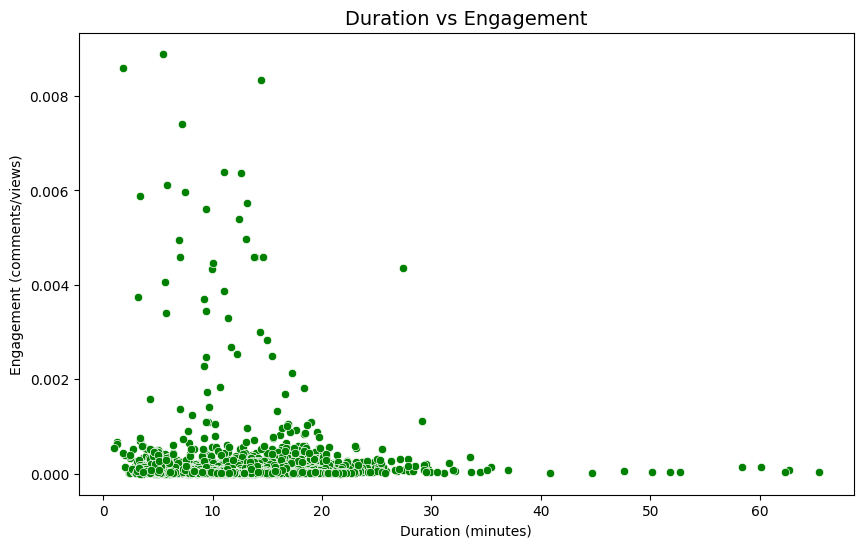

In [104]:
# Chart - 11 Duration vs Engagement
plt.figure(figsize=(10,6))

sns.scatterplot(x='duration_min', y='engagement', data=df, color='green')

plt.title("Duration vs Engagement", fontsize=14)
plt.xlabel("Duration (minutes)")
plt.ylabel("Engagement (comments/views)")

plt.show()

##### 1. Why did you pick the specific chart?

To analyze
Does longer duration increase engagement?

##### 2. What is/are the insight(s) found from the chart?

There is no strong relationship between duration and engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

No clear optimal duration for engagement

#### Chart - 12

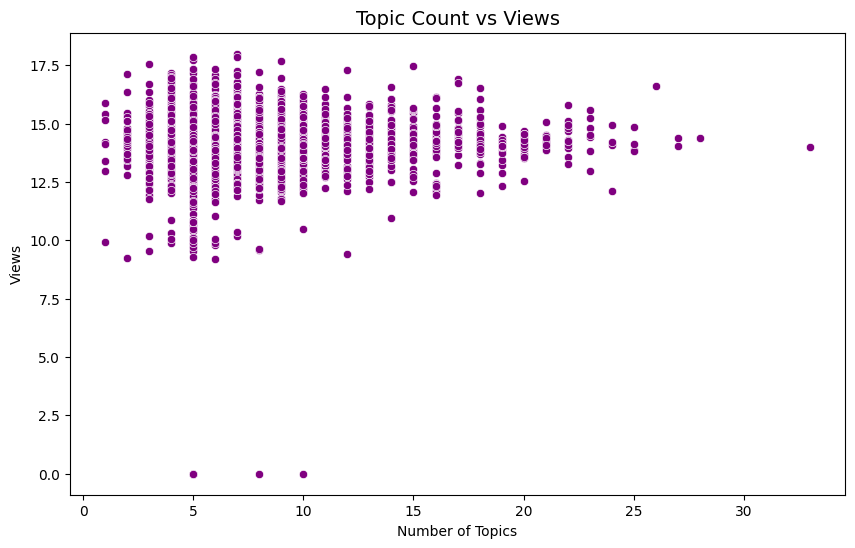

In [105]:
# Chart - 12 Topic Count vs Views
plt.figure(figsize=(10,6))

sns.scatterplot(x='topic_count', y='views', data=df, color='purple')

plt.title("Topic Count vs Views", fontsize=14)
plt.xlabel("Number of Topics")
plt.ylabel("Views")

plt.show()

##### 1. Why did you pick the specific chart?

To analyze does covering more topics = more views?

##### 2. What is/are the insight(s) found from the chart?

Talks with fewer topics tend to perform better, indicating focused content is preferred.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Encourages focused storytelling, improving clarity and audience retention


#### Chart - 13

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

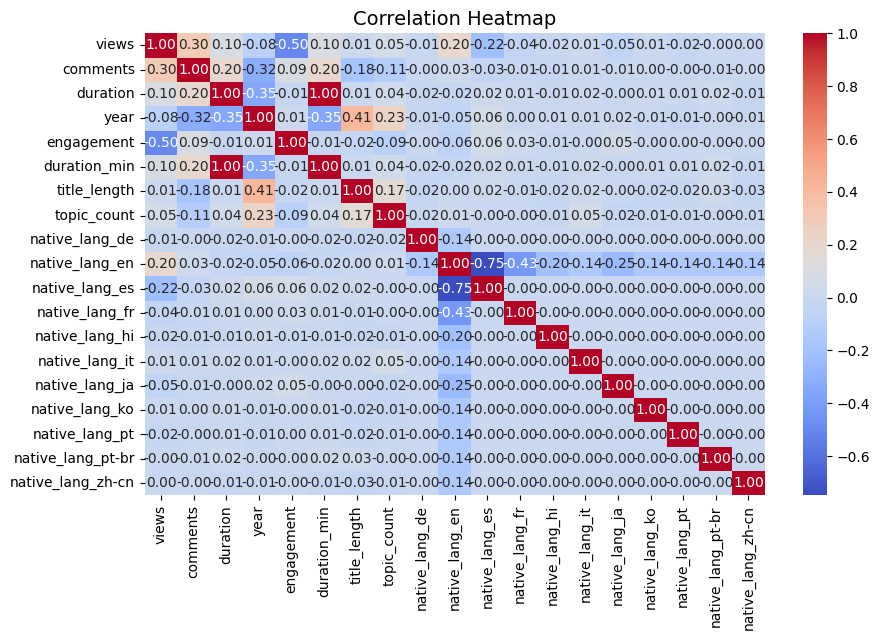

In [106]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap", fontsize=14)

plt.show()

##### 1. Why did you pick the specific chart?

to understand which features are strongly related

##### 2. What is/are the insight(s) found from the chart?

Views and comments , show a strong positive correlation, indicating popular talks get more engagement.

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code
sns.pairplot(
    df[['views','comments','duration_min','engagement']],
    diag_kind='kde',

)

plt.suptitle("Pairwise Relationships Between Key Features",y=1.05 )
plt.show()

##### 1. Why did you pick the specific chart?

Pairplot is used to visualize pairwise relationships between multiple numerical variables in a single view.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***